In [1]:
import os
os.environ['KERAS_BACKEND'] = 'jax'

import numpy as np
import pandas as pd
from scipy.special import expit as sigmoid

import matplotlib.pyplot as plt

import keras
import bayesflow as bf

from joblib import Parallel, delayed
import pickle

INFO:bayesflow:Using backend 'jax'


- Create a true population with infections, get a biased sample from it
- The biased sample represents the data we would get from an actual study
- From the true population, we pretend to know only the distribution of the covariates (and the infectiousness related with these, in a real application, we would also estimate these)
- Hence, we can create an approximation of the true population by stratified sampling from the biased sample

In [2]:
# Known population parameters
age_probs = {'0-19': 0.168, '20-34': 0.25, '35-49': 0.223, '50-64': 0.187, '65-79': 0.118, '80+': 0.054}
gender_probs = {'male': 0.5, 'female': 0.5}
h_size_probs = {'household_1': 0.549, 'household_2': 0.226, 'household_34': 0.124, 'household_5': 0.101}
country_probs = {'Germany': 1-0.35, 'other': 0.35}

cat_to_int = {
    'age': {'0-19': 0, '20-34': 1, '35-49': 2, '50-64': 3, '65-79': 4, '80+': 5},
    'gender': {'male': 0, 'female': 1},
    'h_size': {'household_1': 1, 'household_2': 2, 'household_34': 3, 'household_5': 4},
    'country': {'Germany': 0, 'other': 1}
}

In [3]:
# 1. Sampling from priors
def get_realistic_priors():
    """
    With these priors, the uncorrected prevalence will generally be too low
    compared to the true population prevalence. This is because the sampling
    mechanism systematically underrepresents high-risk groups and overrepresents
    low-risk groups. The corrected prevalence using inverse probability weighting
    should compensate by giving more weight to the under-represented high-risk
    groups, resulting in a higher and more accurate estimate.

    Returns:
        infection_prior_means (dict): prior means for the log-odds model of infection
        infection_prior_stds  (dict): prior stds   for the log-odds model of infection
        inclusion_prior_means (dict): prior means for the log-odds model of inclusion
        inclusion_prior_stds  (dict): prior stds   for the log-odds model of inclusion
    """

    # — Infection model priors (logit scale) — #
    #   baseline intercept roughly expit(-3) ≈ 0.05
    infection_prior_means = {
        'intercept': -3.0,
        # pick 0-19 as reference, then increasing log-odds for older groups
        **{f'age_{g}': delta for g, delta in zip(
            list(age_probs.keys())[1:],
            [0.0, 0.5, 1.0, 1.5, 2.0, 2.5][1:]
        )},
        # pick male as reference (0), female slightly lower odds
        'gender_female': -0.3,
        # household_1 as reference (0), larger HH slightly higher risk
        **{f'h_size_{g}': delta for g, delta in zip(
            list(h_size_probs.keys())[1:],
            [0.0, 0.2, 0.4, 0.6][1:]
        )},
        # country Germany as reference
        'country_other': 0.0
    }
    # keep these fairly tight to encode our prior beliefs
    infection_prior_stds = {
        'intercept':     0.5,
        **{f'age_{g}': 0.5 for g in list(age_probs.keys())[1:]},
        'gender_female': 0.2,
        **{f'h_size_{g}': 0.4 for g in list(h_size_probs.keys())[1:]},
        'country_other': 0.2
    }

    # — Inclusion‐mechanism priors (logit scale) — #
    inclusion_prior_means = {
        'intercept':   -3.5, # -1,
        # older and young age less likely to respond
        **{f'age_{g}': delta for g, delta in zip(
            list(age_probs.keys())[1:],
            #[-0.1, 1.0, 1.0, 1.2, 1.0, 0.2]  # this is more similar to the data
            #[0.0, -1.0, -2.0, -3.0, -4.0, -5.0]  # this is better for demonstration
            #[-1.0, 0.5, -0.5, -1.0, -2.0, -1.0][1:]
            [-1.0, 0.0, -0.5, -0.5, -1.0, -0.5][1:]
        )},
        # women slightly more likely
        'gender_female': 0.5,
        # small decrease for larger HH
        **{f'h_size_{g}': delta for g, delta in zip(
            list(h_size_probs.keys())[1:],
            #[-1.5, 0.1, 0.1, -0.2][1:]
             [-1.5, 1.0, 1.5, -0.2][1:]
        )},
        # country other less likely
        'country_other': -0.3
    }
    inclusion_prior_stds = {
        'intercept':      0.5,
        **{f'age_{g}': 0.7 for g in list(age_probs.keys())[1:]},
        'gender_female':  0.2,
        **{f'h_size_{g}':  0.4 for g in list(h_size_probs.keys())[1:]},
        'country_other':  0.2
    }

    return (infection_prior_means, infection_prior_stds,
            inclusion_prior_means, inclusion_prior_stds)


def sample_logit_models_from_priors(
    infection_covariates, inclusion_covariates,
    infection_prior_means=None, infection_prior_stds=None,
    inclusion_prior_means=None, inclusion_prior_stds=None,
    default_mean=0.0, default_std=1.0, seed=None
):
    if seed is not None:
        np.random.seed(seed)

    def sample_params(covariates, means, stds):
        means = means or {}
        stds = stds or {}
        return {
            cov: np.random.normal(loc=means.get(cov, default_mean), scale=stds.get(cov, default_std))
            for cov in covariates
        }

    infection_params_dict = sample_params(infection_covariates, infection_prior_means, infection_prior_stds)
    inclusion_params_dict = sample_params(inclusion_covariates, inclusion_prior_means, inclusion_prior_stds)

    return infection_params_dict, inclusion_params_dict

In [4]:
# 2. Simulate a population
def simulate_population(
    n,
    infection_logit_params,
    inclusion_logit_params,
    oversample_factor,
    biased_sample=True,
    missing_data=True
):
    """
    Simulate a true population of size n*oversample_factor, draw a biased sample of size n,
    and return the sampled DataFrame plus the true prevalence in the full pool.

    infection_logit_params & inclusion_logit_params are dicts from your get_realistic_priors(),
    with keys like 'intercept', 'age_0-19', ..., 'gender_female', 'region_household_1', ..., 'country_other'.
    """
    # 1) build the big pool
    n_pool = n * oversample_factor

    age    = np.random.choice(list(age_probs.keys()),     size=n_pool, p=list(age_probs.values()))
    gender = np.random.choice(list(gender_probs.keys()),  size=n_pool, p=list(gender_probs.values()))
    h_size = np.random.choice(list(h_size_probs.keys()),  size=n_pool, p=list(h_size_probs.values()))
    country= np.random.choice(list(country_probs.keys()), size=n_pool, p=list(country_probs.values()))

    df = pd.DataFrame({
        'age':     age,
        'gender':  gender,
        'h_size':  h_size,
        'country': country,
    })

    # 2) one-hot encode all categories
    #    will produce columns like 'age_0-19',..., 'gender_female', 'h_size_household_1',..., 'country_other'
    df_enc = pd.get_dummies(df, columns=['age','gender','h_size','country'], drop_first=False)

    # 3) inclusion probabilities
    lin_inc = np.full(n_pool, inclusion_logit_params.get('intercept', 0.0))
    for k, v in inclusion_logit_params.items():
        if k == 'intercept': continue
        # add v * indicator for that category
        lin_inc += v * df_enc.get(k, 0.0)
    inc_prob = sigmoid(lin_inc)
    # normalize to sum to 1 so we can sample
    inc_weights = inc_prob / inc_prob.sum()
    df['inclusion_prob'] = inc_weights

    # 4) infection status
    if not biased_sample:
        # purely random prevalence between 0–60%
        p = np.random.uniform(0.001, 0.6)
        df['infection'] = np.random.binomial(1, p, size=n_pool)
    else:
        lin_inf = np.full(n_pool, infection_logit_params.get('intercept', 0.0))
        for k, v in infection_logit_params.items():
            if k == 'intercept': continue
            lin_inf += v * df_enc.get(k, 0.0)
        p_inf = sigmoid(lin_inf)
        df['infection'] = np.random.binomial(1, p_inf, size=n_pool)

    # 5) sample n draws with replacement by the inclusion_weights
    sampled_idx = np.random.choice(n_pool, size=n, replace=True, p=inc_weights)
    df_sampled = df.iloc[sampled_idx].reset_index(drop=True)

    # 6) compute true prevalence in the full pool
    prev_full_dataset = df['infection'].mean()

    # 7) assign household IDs by h_size category
    # map category to maximum household size
    hh_ids = pd.Series(index=df_sampled.index, dtype=str)
    # assign households within each category
    for cat, max_size in cat_to_int['h_size'].items():
        idx_list = df_sampled.index[df_sampled['h_size'] == cat].tolist()
        np.random.shuffle(idx_list)
        ptr = 0
        hh_counter = 0
        while ptr < len(idx_list):
            actual = np.random.randint(1, max_size + 1)
            group = idx_list[ptr:ptr + actual]
            for row in group:
                hh_ids.at[row] = f"{cat}_HH{hh_counter}"
            ptr += actual
            hh_counter += 1
    df_sampled['household_id'] = hh_ids.values

    # 8) introduce missingness by household
    # for each household, probability of missing increases if any member there
    df_sampled['infection_true'] = df_sampled['infection'].copy()
    if missing_data:
        base_infection_missing = np.clip(np.random.normal(0.2, 0.03), 0, 1)
        base_other_missing = np.clip(np.random.normal(0.05, 0.03), 0, 1)
        cols = ['infection', 'age', 'gender', 'h_size', 'country']
        # Generate all random values at once
        random_vals = np.random.rand(len(df_sampled), len(cols))
        for hh, indices in df_sampled.groupby('household_id').groups.items():
            infection_multiplier = len(indices)  # Only for infection column
            for idx in indices:
                for j, col in enumerate(cols):
                    base = base_infection_missing if col == 'infection' else base_other_missing
                    multiplier = infection_multiplier if col == 'infection' else 1
                    prob = base * multiplier

                    if random_vals[idx, j] < prob:
                        df_sampled.at[idx, col] = np.nan
    # order by household_id
    df_sampled.sort_values('household_id', inplace=True)
    # renumber the ids
    df_sampled['household_id'] = pd.factorize(df_sampled['household_id'])[0]
    return df_sampled, prev_full_dataset

In [5]:
def estimate_inclusion_weights_from_known_population(
    df_sampled: pd.DataFrame,
    use_simulated_weights: bool = False
) -> np.ndarray:
    """
    Estimate inclusion probabilities based on known population parameters.

    Args:
        df_sampled: The sampled dataframe with categorical columns 'age', 'gender',
                    'region', and 'country'.
        use_simulated_weights: If True, use known weights from simulations.

    Returns:
        weights: array of estimated inclusion weights for each sampled observation.
    """
    if not use_simulated_weights:
        # Initialize weights
        weights = np.ones(len(df_sampled), dtype=float)

        # 1) Adjust for age distribution
        for age_cat, pop_prob in age_probs.items():
            mask = df_sampled['age'] == age_cat
            sample_prob = mask.mean()
            if sample_prob > 0:
                weights[mask] *= pop_prob / sample_prob

        # 2) Adjust for gender distribution
        for gender_cat, pop_prob in gender_probs.items():
            mask = df_sampled['gender'] == gender_cat
            sample_prob = mask.mean()
            if sample_prob > 0:
                weights[mask] *= pop_prob / sample_prob

        # 3) Adjust for region distribution
        for region_cat, pop_prob in h_size_probs.items():
            mask = df_sampled['h_size'] == region_cat
            sample_prob = mask.mean()
            if sample_prob > 0:
                weights[mask] *= pop_prob / sample_prob

        # 4) Adjust for country distribution
        for country_cat, pop_prob in country_probs.items():
            mask = df_sampled['country'] == country_cat
            sample_prob = mask.mean()
            if sample_prob > 0:
                weights[mask] *= pop_prob / sample_prob

        # Convert weights into inclusion probabilities: higher weight => lower inclusion prob
        # Normalize then invert
        weights[np.isnan(weights)] = np.median(weights)  # imputation of missing covariates
        weights = weights / weights.mean()
        inclusion_probs = 1 / weights                 # relative inclusion probability
        inclusion_probs = inclusion_probs / inclusion_probs.sum()       # normalize across sample

        # inclusion probs should be nan if infection is nan
        inclusion_probs[np.isnan(df_sampled['infection'])] = np.nan
    else:
        # use provided inclusion_prob if available
        inclusion_probs = df_sampled.get('inclusion_prob').values

    # Compute first-order inclusion probability over n draws
    n = len(df_sampled)
    p_inc = 1.0 - np.power(1.0 - inclusion_probs, n)
    p_inc = np.clip(p_inc, 1e-3, 1.0)

    # Final inclusion weights: inverse of selection probability
    weights_final = 1.0 / p_inc
    return weights_final


def estimate_prevalence(
    sampled_df: pd.DataFrame,
    bootstrap,
    use_simulated_weights = False
):
    """
    Estimate uncorrected and (optionally) corrected prevalence via inclusion weighting.

    Args:
        sampled_df: DataFrame containing 'infection' and categorical columns.
        bootstrap: If True, return bootstrap distributions as well.
        use_simulated_weights: If True, use weights from simulations.

    Returns:
        If bootstrap=False:
            (uncorrected, corrected)
        Else:
            (uncorrected, corrected,
             bootstrap_uncorrected, bootstrap_corrected)
    """
    # Uncorrected prevalence (does not count nan values)
    uncorrected = sampled_df['infection'].mean()

    # Estimated inclusion weights
    if not use_simulated_weights:
        sampled_df['inclusion_weights_estimated'] = estimate_inclusion_weights_from_known_population(
            sampled_df,
            use_simulated_weights=False
        )
        # Corrected prevalence: weighted average
        corrected = np.nansum(sampled_df.loc[sampled_df['infection'] == 1, 'inclusion_weights_estimated']) / np.nansum(sampled_df['inclusion_weights_estimated'])
    else:
        sampled_df['inclusion_weights_estimated'] = estimate_inclusion_weights_from_known_population(
            sampled_df,
            use_simulated_weights=True
        )
        # Corrected prevalence: weighted average (no nan values)
        corrected = np.sum(sampled_df.loc[sampled_df['infection_true'] == 1, 'inclusion_weights_estimated']) / np.sum(sampled_df['inclusion_weights_estimated'])
    sampled_df.pop('inclusion_weights_estimated')

    if bootstrap:
        boot_uncorrected = bootstrap_prevalence(sampled_df, weight_samples=False)
        boot_corrected = bootstrap_prevalence(
            sampled_df,
            weight_samples=True,
            use_simulated_weights=use_simulated_weights
        )
        return uncorrected, corrected, boot_uncorrected, boot_corrected
    return uncorrected, corrected


def bootstrap_prevalence(
    sampled_df: pd.DataFrame,
    weight_samples: bool = True,
    n_bootstrap: int = 100,
    use_simulated_weights: bool = False,
) -> np.ndarray:
    """
    Use bootstrapping to estimate weighted prevalence.

    Args:
        sampled_df: DataFrame with 'infection' column.
        weight_samples: If True, apply inclusion weight estimation.
        n_bootstrap: Number of bootstrap samples.
        use_simulated_weights: If True, use weights from simulations.

    Returns:
        Array of bootstrap prevalence estimates.
    """
    n = len(sampled_df)
    boot_est = np.zeros(n_bootstrap)

    for i_b in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        df_boot = sampled_df.iloc[idx]
        if weight_samples:
            if not use_simulated_weights:
                w = estimate_inclusion_weights_from_known_population(
                    df_boot,
                    use_simulated_weights=False
                )
                infected_idx = df_boot['infection'] == 1
                if np.sum(infected_idx) > 0:
                    boot_est[i_b] = np.nansum(w[infected_idx]) / np.nansum(w)
            else:
                w = estimate_inclusion_weights_from_known_population(
                    df_boot,
                    use_simulated_weights=True
                )
                infected_idx = df_boot['infection_true'] == 1  # has no nan values
                boot_est[i_b] = np.sum(w[infected_idx]) / np.sum(w)
        else:
            boot_est[i_b] = df_boot['infection'].mean()
    return boot_est

In [6]:
infection_means, infection_stds, inclusion_means, inclusion_stds = get_realistic_priors()

infection_params, inclusion_params = sample_logit_models_from_priors(
            infection_covariates=list(infection_means.keys()),
            inclusion_covariates= list(inclusion_means.keys()),
            infection_prior_means=infection_means,
            infection_prior_stds=infection_stds,
            inclusion_prior_means=inclusion_means,
            inclusion_prior_stds=inclusion_stds,
        )

# simulate and sample
df_samp_test, true_prev = simulate_population(
            n=500,
            infection_logit_params=infection_params,
            inclusion_logit_params=inclusion_params,
            oversample_factor=10,
        )

print(true_prev)
df_samp_test.head()

0.072


,age,gender,h_size,country,inclusion_prob,infection,household_id,infection_true
242,35-49,female,household_1,Germany,0.000363,0.0,0,0
51,35-49,female,household_1,NaN,0.000363,0.0,1,0
55,50-64,female,household_1,Germany,0.000176,NaN,2,1
196,20-34,female,NaN,Germany,0.000248,0.0,3,0
265,80+,female,household_1,Germany,0.000125,NaN,4,0


In [7]:
# 4. Run simulation study
@delayed
def run_simulation_study(
    n_runs: int,
    sample_target: int,
    biased_sample: bool = True,
    missing_data: bool = True,
    oversample_factor: int = 10
):
    """
    Perform a simulation study drawing parameters from priors,
    simulating a population, sampling and estimating prevalence.

    Args:
        n_runs: number of simulation replicates
        sample_target: survey sample size per replicate
        biased_sample: whether to draw sample using inclusion bias
        missing_data: whether to introduce missing data
        oversample_factor: factor to enlarge the simulated pool

    Returns:
        uncorrected_prevs: (n_runs,) array of uncorrected prevalence estimates
        corrected_prevs:   (n_runs,) array of bias-corrected estimates
        true_prevs:        (n_runs,) array of true prevalences in the full population
        bootstrap_prevs:   (n_runs,) array of bootstrap distributions of uncorrected estimates
        bootstrap_cor_prevs: (n_runs,) array of bootstrap distributions of corrected estimates
        bootstrap_cor_true_prevs: (n_runs,) array of bootstrap distributions corrected with true weights
    """
    uncorrected_prevs = []
    corrected_prevs = []
    true_prevs = []
    bootstrap_prevs = []
    bootstrap_cor_prevs = []
    bootstrap_cor_true_prevs = []

    for i in range(n_runs):
        # sample model parameters from priors
        infection_params_dict, inclusion_params_dict = sample_logit_models_from_priors(
            infection_covariates=list(infection_means.keys()),
            inclusion_covariates= list(inclusion_means.keys()),
            infection_prior_means=infection_means,
            infection_prior_stds=infection_stds,
            inclusion_prior_means=inclusion_means,
            inclusion_prior_stds=inclusion_stds,
            #seed=i
        )

        # simulate and sample
        df_samp, prev_full_dataset = simulate_population(
            n=sample_target,
            infection_logit_params=infection_params_dict,
            inclusion_logit_params=inclusion_params_dict,
            oversample_factor=oversample_factor,
            biased_sample=biased_sample,
            missing_data=missing_data
        )

        # estimate prevalences with bootstrap
        uncor, cor, boot_uncor, boot_cor = estimate_prevalence(
            df_samp,
            bootstrap=True,
            use_simulated_weights=False
        )

        # estimate prevalences with bootstrap and weights from simulation
        _, _, _, boot_cor_true = estimate_prevalence(
            df_samp,
            bootstrap=True,
            use_simulated_weights=True
        )

        # store
        true_prevs.append(prev_full_dataset)
        uncorrected_prevs.append(uncor)
        corrected_prevs.append(cor)
        bootstrap_prevs.append(boot_uncor)
        bootstrap_cor_prevs.append(boot_cor)
        bootstrap_cor_true_prevs.append(boot_cor_true)

    return (
        np.array(uncorrected_prevs),
        np.array(corrected_prevs),
        np.array(true_prevs),
        np.array(bootstrap_prevs),
        np.array(bootstrap_cor_prevs),
        np.array(bootstrap_cor_true_prevs)
    )

# Run in parallel
def run_simulation_study_parallel(n_runs, sample_target, missing_data):
    uncor_prev = []
    cor_prev = []
    true_prev = []
    bootstrap_prev = []
    bootstrap_cor_prev = []
    bootstrap_cor_true_prev = []
    parallel_list = Parallel(n_jobs=-1, verbose=1)(run_simulation_study(n_runs=10, sample_target=sample_target,
                                                                        missing_data=missing_data) for _ in range(n_runs//10))
    for pl in parallel_list:
        a, b, c, d, e, f = pl
        uncor_prev.append(a)
        cor_prev.append(b)
        true_prev.append(c)
        bootstrap_prev.append(d)
        bootstrap_cor_prev.append(e)
        bootstrap_cor_true_prev.append(f)
    uncor_prev = np.concatenate(uncor_prev, axis=0)
    cor_prev = np.concatenate(cor_prev, axis=0)
    true_prev = np.concatenate(true_prev, axis=0)
    bootstrap_prev = np.concatenate(bootstrap_prev, axis=0)
    bootstrap_cor_prev = np.concatenate(bootstrap_cor_prev, axis=0)
    bootstrap_cor_true_prev = np.concatenate(bootstrap_cor_true_prev, axis=0)
    return uncor_prev, cor_prev, true_prev, bootstrap_prev, bootstrap_cor_prev, bootstrap_cor_true_prev

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:    9.7s remaining:   38.9s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    9.9s finished


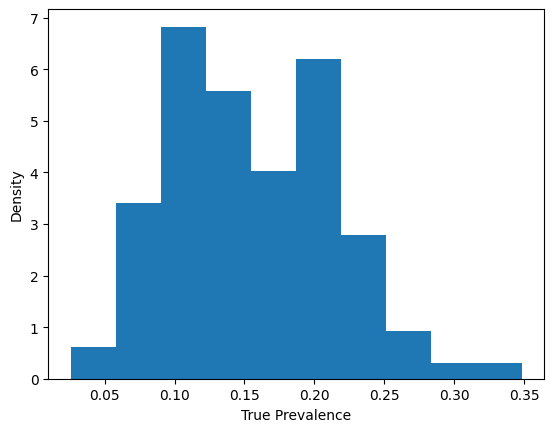

VariableArray([0.0939804 , 0.03543668, 0.03232345])

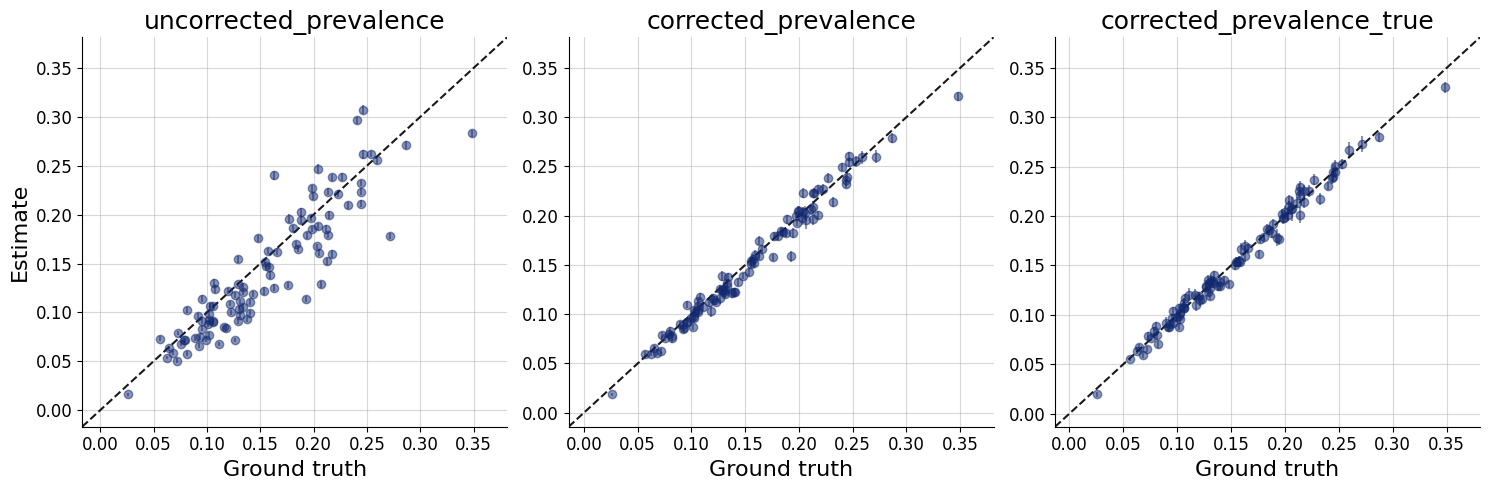

In [8]:
dataset_size = 5000
n_r = 100

np.random.seed(42)
uncor_prev, cor_prev, true_prev, bootstrap_prev, bootstrap_cor_prev, bootstrap_cor_true_prev\
    = run_simulation_study_parallel(n_runs=n_r, sample_target=dataset_size, missing_data=False)

plt.hist(true_prev, density=True)
plt.xlabel('True Prevalence')
plt.ylabel('Density')
plt.show()
#
# bf.diagnostics.recovery(np.concatenate((uncor_prev[:, np.newaxis, np.newaxis], cor_prev[:, np.newaxis, np.newaxis]), axis=-1),
#                         np.stack((true_prev, true_prev), axis=-1),
#                         variable_names=['uncorrected_prevalence', 'corrected_prevalence'],
#                         add_corr=False)
estimates = np.concatenate((bootstrap_prev[:, :, np.newaxis],
                            bootstrap_cor_prev[:, :, np.newaxis],
                            bootstrap_cor_true_prev[:, :, np.newaxis]), axis=-1)
target = np.stack((true_prev, true_prev, true_prev), axis=-1)
bf.diagnostics.recovery(estimates, target,
                        variable_names=['uncorrected_prevalence', 'corrected_prevalence', 'corrected_prevalence_true'],
                        add_corr=False)

bf.diagnostics.metrics.root_mean_squared_error(estimates, target)['values']

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  10 | elapsed:   11.3s remaining:   45.0s


with missing data


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   11.6s finished


VariableArray([0.08628477, 0.04853192, 0.03300641])

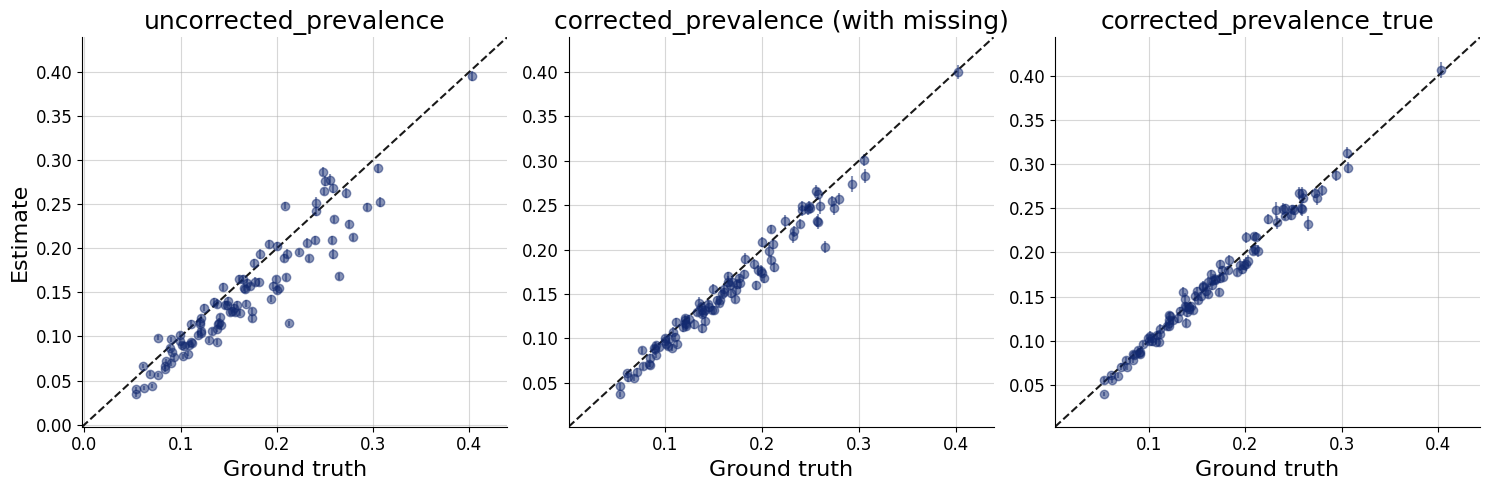

In [9]:
np.random.seed(42)
uncor_prev, cor_prev, true_prev, bootstrap_prev, bootstrap_cor_prev, bootstrap_cor_true_prev\
    = run_simulation_study_parallel(n_runs=n_r, sample_target=dataset_size, missing_data=True)
print('with missing data')
# bf.diagnostics.recovery(np.concatenate((uncor_prev[:, np.newaxis, np.newaxis], cor_prev[:, np.newaxis, np.newaxis]), axis=-1),
#                         np.stack((true_prev, true_prev), axis=-1),
#                         variable_names=['uncorrected_prevalence', 'corrected_prevalence'],
#                         add_corr=False)
estimates = np.concatenate((bootstrap_prev[:, :, np.newaxis],
                            bootstrap_cor_prev[:, :, np.newaxis],
                            bootstrap_cor_true_prev[:, :, np.newaxis]), axis=-1)
target = np.stack((true_prev, true_prev, true_prev), axis=-1)
bf.diagnostics.recovery(estimates, target,
                        variable_names=['uncorrected_prevalence', 'corrected_prevalence (with missing)', 'corrected_prevalence_true'],
                        add_corr=False)

bf.diagnostics.metrics.root_mean_squared_error(estimates, target)['values']

In [10]:
# rmse_uncor_list, rmse_cor_list = [], []
# pop_sizes = np.arange(100, 1001, 100)
# for pop_size in pop_sizes:
#     _uncor_prev, _cor_prev, _true_prev, _, _, _ = run_simulation_study(n_runs=20, sample_target=pop_size)
#     rmse_uncor_list.append(rmse(_uncor_prev, _true_prev))
#     rmse_cor_list.append(rmse(_cor_prev, _true_prev))
#
# plt.plot(pop_sizes, rmse_uncor_list, label='uncorrected')
# plt.plot(pop_sizes, rmse_cor_list, label='corrected')
# plt.xlabel('Population Size')
# plt.ylabel('RMSE')
# plt.legend()
# plt.show()

In [11]:
def convert_to_nn_input(new_population: pd.DataFrame) -> np.ndarray:
    new_population_nn = new_population.copy()
    # convert categorical variables to integers
    for cat in cat_to_int:
        new_population_nn[cat] = new_population_nn[cat].map(cat_to_int[cat])

    # count number of infections in each household
    infections_hh = new_population_nn.groupby('household_id').agg({'infection': 'sum'})
    new_population_nn['num_infections_in_hh'] = new_population_nn['household_id'].map(infections_hh['infection'])

    # normalize the household id
    new_population_nn['household_id'] = new_population_nn['household_id'] / len(new_population_nn)

    # keep only the relevant columns
    new_population_nn = new_population_nn[['infection', 'household_id', 'num_infections_in_hh']+list(cat_to_int.keys())]

    # convert to numpy array
    new_population_nn = new_population_nn.values * 1
    new_population_nn[np.isnan(new_population_nn)] = -1
    return new_population_nn


def convert_to_nn_long_input(new_population: pd.DataFrame, n_rows) -> np.ndarray:
    new_population_nn = new_population.copy()
    # convert categorical variables to integers
    for cat in cat_to_int:
        new_population_nn[cat] = new_population_nn[cat].map(cat_to_int[cat])
    # normalize the household id
    new_population_nn['household_id'] = new_population_nn['household_id'] / len(new_population_nn)

    # keep only the relevant columns
    new_population_nn = new_population_nn[['infection', 'household_id']+list(cat_to_int.keys())]

    # assign slot number within each household
    new_population_nn['slot'] = new_population_nn.groupby('household_id').cumcount() + 1

    # identify your covariate columns
    covs = [c for c in new_population_nn.columns if c not in ('household_id','slot')]

    # fill missing values with -1
    new_population_nn[covs] = new_population_nn[covs].fillna(-1)

    # pivot all covariates at once, filling missing with -2
    new_population_nn = new_population_nn.pivot_table(
        index='household_id',
        columns='slot',
        values=covs,
        aggfunc='first',
        fill_value=-2  # missing because no more members in household
    )

    # explicitly reindex the MultiIndex so slots 1–5 exist for every cov
    full_cols = pd.MultiIndex.from_product([covs, range(1,6)], names=(None, 'slot'))
    new_population_nn = new_population_nn.reindex(columns=full_cols, fill_value=-2)

    # flatten the MultiIndex columns: e.g. ('age',2) → 'age_2'
    new_population_nn.columns = [f"{cov}_{slot}" for cov, slot in new_population_nn.columns]

    # make sure you have slots 1–5 for each cov (pivot_table did that)
    # and reset index so household_id is a column again
    new_population_nn.reset_index(inplace=True)
    new_population_nn.drop(columns=['household_id', 'h_size_2', 'h_size_3','h_size_4','h_size_5'], inplace=True)

    # convert to numpy array
    new_population_nn = new_population_nn.values * 1

    if n_rows is not None:
        # expand to n_rows, fill with -2
        out = np.zeros((n_rows, new_population_nn.shape[1]))
        out.fill(-2)
        n_rows = min(n_rows, new_population_nn.shape[0])
        out[:n_rows] = new_population_nn[:n_rows]
    else:
        out = new_population_nn
    return out

In [12]:
# test conversion
test = convert_to_nn_long_input(df_samp_test, 1000)
test

array([[ 0., -2., -2., ..., -2., -2., -2.],
       [ 0., -2., -2., ..., -2., -2., -2.],
       [-1., -2., -2., ..., -2., -2., -2.],
       ...,
       [-2., -2., -2., ..., -2., -2., -2.],
       [-2., -2., -2., ..., -2., -2., -2.],
       [-2., -2., -2., ..., -2., -2., -2.]])

In [13]:
param_names = ['prevalence']

def prior_bf():
    """Get the prior distribution for the parameters."""
    infection_params_dict, inclusion_params_dict = sample_logit_models_from_priors(
                infection_covariates=list(infection_means.keys()),
                inclusion_covariates=list(inclusion_means.keys()),
                infection_prior_means=infection_means,
                infection_prior_stds=infection_stds,
                inclusion_prior_means=inclusion_means,
                inclusion_prior_stds=inclusion_stds
            )
    out_1 = {'infection_'+k: v for k, v in infection_params_dict.items()}
    out_2 = {'inclusion_'+k: v for k, v in inclusion_params_dict.items()}
    return {**out_1, **out_2}

def simulator_bf(pop_size=5583, bootstrap=False, **kwargs):
    infection_params_dict = {k: kwargs['infection_' + k] for k in list(infection_means.keys())}
    inclusion_params_dict = {k: kwargs['inclusion_' + k] for k in list(inclusion_means.keys())}

    # generate a new population
    new_population, prev_full_dataset = simulate_population(
        n=pop_size,
        infection_logit_params=infection_params_dict,
        inclusion_logit_params=inclusion_params_dict,
        oversample_factor=10
    )

    if bootstrap:
        uncor_prev, cor_prev, b_estimates, b_estimates_cor = estimate_prevalence(new_population, bootstrap=True)
        _, _, _, b_estimates_cor_true = estimate_prevalence(new_population, bootstrap=True, use_simulated_weights=True)
        reference_bootstrap = b_estimates[:, np.newaxis]
        reference_bootstrap_cor = b_estimates_cor[:, np.newaxis]
        reference_bootstrap_cor_true = b_estimates_cor_true[:, np.newaxis]
    else:
        uncor_prev, cor_prev = estimate_prevalence(new_population, bootstrap=False)
        reference_bootstrap = None
        reference_bootstrap_cor = None
        reference_bootstrap_cor_true = None

    # save the data and parameters
    out_dict = {
        #'sim_data': convert_to_nn_input(new_population),
        'sim_data': convert_to_nn_long_input(new_population, n_rows=int(pop_size * 2/3)),
        'prevalence': prev_full_dataset,
        'reference_bootstrap': reference_bootstrap,
        'reference_bootstrap_cor': reference_bootstrap_cor,
        'reference_bootstrap_cor_true': reference_bootstrap_cor_true,
        'reference': cor_prev,
        'reference_biased': uncor_prev,
        'bias_sample': (prev_full_dataset - uncor_prev)**2 > 0.05
    }
    return out_dict

@delayed
def simulate_parallel(pop_size=5583, bootstrap=False, **kwargs):
    return simulator_bf(pop_size=pop_size, bootstrap=bootstrap, **kwargs)

generative_model = bf.make_simulator([prior_bf, simulator_bf])

In [14]:
def list_of_dicts_to_dict_of_lists(list_of_dicts):
    # Check if the list is empty
    if not list_of_dicts:
        return {}

    # Initialize the dictionary of arrays
    dict_of_arrays = {key: [] for key in list_of_dicts[0]}

    # Populate the dictionary of arrays
    for dictionary in list_of_dicts:
        for key, value in dictionary.items():
            dict_of_arrays[key].append(value)
    for k in dict_of_arrays:
        dict_of_arrays[k] = np.array(dict_of_arrays[k])
    return dict_of_arrays

In [15]:
batch_size = 32
num_training_batches = 500
num_validation_sets = 50

training_data_file = f'training_data_prevalence.pickle'
validation_data_file = f'valid_data_prevalence.pickle'

if os.path.exists(training_data_file):
    # load simulation data
    with open(training_data_file, 'rb') as f:
        training_data = pickle.load(f)
    with open(validation_data_file, 'rb') as f:
        validation_data = pickle.load(f)
else:
    prior_samples_train = [prior_bf() for _ in range(num_training_batches * batch_size)]
    simulations = Parallel(n_jobs=-1, verbose=1)(simulate_parallel(**prior_sample) for prior_sample in prior_samples_train)
    training_data = list_of_dicts_to_dict_of_lists(prior_samples_train)
    simulations_array = list_of_dicts_to_dict_of_lists(simulations)
    training_data.update(simulations_array)

    prior_samples_valid = [prior_bf() for _ in range(num_validation_sets * batch_size)]
    simulations_valid = Parallel(n_jobs=-1, verbose=1)(simulate_parallel(bootstrap=True, **prior_sample) for prior_sample in prior_samples_valid)
    validation_data = list_of_dicts_to_dict_of_lists(prior_samples_valid)
    simulations_array = list_of_dicts_to_dict_of_lists(simulations_valid)
    validation_data.update(simulations_array)

    training_data['prevalence'] = training_data['prevalence'][:, np.newaxis]
    validation_data['prevalence'] = validation_data['prevalence'][:, np.newaxis]

    # pickle
    with open(training_data_file, 'wb') as f:
        pickle.dump(training_data, f)
    with open(validation_data_file, 'wb') as f:
        pickle.dump(validation_data, f)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done 840 tasks      | elapsed:   18.3s
[Parallel(n_jobs=-1)]: Done 1540 tasks      | elapsed:   32.5s
[Parallel(n_jobs=-1)]: Done 2440 tasks      | elapsed:   50.7s
[Parallel(n_jobs=-1)]: Done 3540 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 4840 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 6340 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done 8040 tasks      | elapsed:  2.9min
[Parallel(n_jobs=-1)]: Done 9940 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 12040 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done 14340 tasks      | elapsed:  4.9min
[Parallel(n_jobs=-1)]: Done 16000 out of 16000 | elapsed:  5.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs

In [16]:
adapter = (
    bf.adapters.Adapter()
    .to_array()
    .convert_dtype(from_dtype="float64", to_dtype="float32")
    .constrain("prevalence", lower=0, upper=1, inclusive='both')
    .rename("prevalence", to_key="inference_variables")
    .rename('sim_data', to_key="summary_variables")
    .standardize('inference_variables')
)

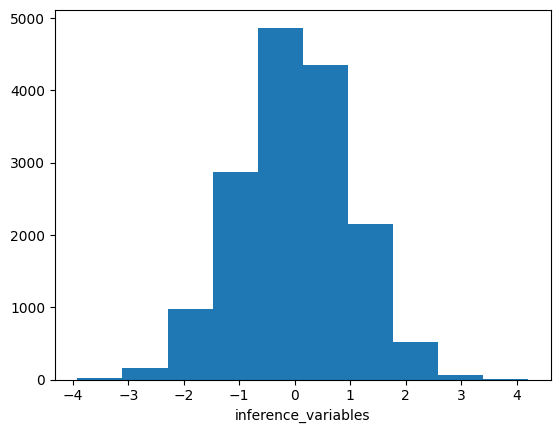

In [18]:
plt.hist(adapter.forward(training_data)["inference_variables"])
plt.xlabel('inference_variables')
plt.show()

In [21]:
epochs = 25
workflow = bf.BasicWorkflow(
    simulator=generative_model,
    adapter=adapter,
    summary_network=bf.networks.DeepSet(summary_dim=10,
                                        mlp_widths_equivariant=(128, 128, 128),
                                        mlp_widths_invariant_inner=(128, 128, 128),
                                        mlp_widths_invariant_outer=(128, 128, 128)),
    inference_network=bf.networks.CouplingFlow()
    #inference_network=bf.networks.ConsistencyModel(epochs*training_data['sim_data'].shape[0])
    #inference_network=bf.networks.FlowMatching()
)

model_path = f'models/prevalence_long.keras'
if os.path.exists(model_path):
    workflow.approximator = keras.saving.load_model(filepath=model_path)
else:
    history = workflow.fit_offline(
        data=training_data,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=validation_data,
    )
    workflow.approximator.save(model_path)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/25
  4/500 ━━━━━━━━━━━━━━━━━━━━ 32:29 4s/step - loss: 1.4766 - loss/inference_loss: 1.4766

KeyboardInterrupt: 

In [ ]:
workflow.plot_default_diagnostics(test_data=validation_data, calibration_ecdf_kwargs={'difference': True})

In [ ]:
posterior_samples = workflow.sample(num_samples=validation_data['reference_bootstrap'].shape[1], conditions=validation_data)

In [ ]:
if len(param_names) == 1:
    estimates = np.concatenate((validation_data['reference_bootstrap'],
                                            validation_data['reference_bootstrap_cor'],
                                            validation_data['reference_bootstrap_cor_true'],
                                            posterior_samples['prevalence']), axis=-1)
    ground_truth = np.concatenate((validation_data['prevalence'], validation_data['prevalence'],
                                   validation_data['prevalence'], validation_data['prevalence']), axis=-1)
    variable_names = ['Uncorrected\nPrevalence\n', 'Weighted\nPrevalence\n', 'Weighted\nPrevalence\n(no missing)', 'NPE\nPrevalence\nPrediction']

    fig = bf.diagnostics.recovery(estimates, ground_truth, variable_names=variable_names, add_corr=False, figsize=(9, 3))
    #fig.savefig(f'plots/recovery_prevalence.pdf', bbox_inches='tight')
    rmse_bf = bf.diagnostics.metrics.root_mean_squared_error(estimates, ground_truth)['values']
    print(rmse_bf)

# Application to KoCo19 data

In [ ]:
np.random.seed(42)
prev_list = []
prev_list_q = []
prev_list_samples = []
for i in range(1, 6):
    koco_df = pd.read_csv(f'KoCo/koco19_T{i}.csv')  # column names: HH_ID, hh_size, pos, sex,age, timepoint

    # define bins and labels
    bins   = [0, 20, 35, 50, 65, 80, np.inf]
    labels = ['0-19', '20-34', '35-49', '50-64', '65-79', '80+']

    #koco_df = koco_df[~np.isnan(koco_df['pos'])]
    #koco_df.loc[np.isnan(koco_df['pos']), 'pos'] = 0

    # create the age_group column
    koco_df['_age'] = koco_df['age']
    koco_df['age'] = pd.cut(koco_df['age'],
                             bins=bins,
                             labels=labels,
                             right=False).astype('object')  # intervals are [left, right)

    koco_df['gender'] = koco_df['sex'].map({'f': 'female', 'm': 'male'})
    koco_df['country'] = koco_df['birth_country']
    koco_df['h_size'] = koco_df['hh_size'].map({1: 'household_1', 2: 'household_2',
                                                 3: 'household_34', 4: 'household_34',
                                                 5: 'household_5'})
    koco_df.sort_values('h_size', inplace=True)
    koco_df['household_id'] = pd.factorize(koco_df['HH_ID'])[0]

    # rename columns
    koco_df['infection'] = koco_df['pos']
    koco_df.pop('HH_ID')
    koco_df.pop('hh_size')
    koco_df.pop('pos')
    koco_df.pop('sex')
    koco_df.pop('timepoint')
    koco_df.pop('birth_country')

    _, _, b_estimates, b_estimates_cor = estimate_prevalence(koco_df, bootstrap=True)
    uncorrected_quantile = np.quantile(b_estimates, [0.025, 0.975])
    corrected_quantile = np.quantile(b_estimates_cor, [0.025, 0.975])
    print(i)
    print(f"Uncorrected prevalence: {np.median(b_estimates)*100}, {uncorrected_quantile*100}")
    print(f"Corrected prevalence: {np.median(b_estimates_cor)*100}, {corrected_quantile*100}")

    # now with NPE
    #posterior_samples = workflow.sample(num_samples=100, conditions=dict(sim_data=convert_to_nn_long_input(koco_df,
    #                                                                                                       n_rows=int(koco_df.shape[0]*2/3))[np.newaxis]))
    #posterior_samples = workflow.sample(num_samples=100, conditions=dict(sim_data=convert_to_nn_long_input(koco_df,
    #                                                                                                       n_rows=None)[np.newaxis]))
    posterior_samples = workflow.sample(num_samples=100, conditions=dict(sim_data=convert_to_nn_input(koco_df)[np.newaxis]))
    posterior_samples = posterior_samples['prevalence'].flatten()
    npe_quantile = np.quantile(posterior_samples, [0.025, 0.975])
    print(f"NPE prevalence: {np.median(posterior_samples)*100}, {npe_quantile*100}")

    prev_list.append([np.median(b_estimates), np.median(b_estimates_cor), np.median(posterior_samples)])
    prev_list_q.append([uncorrected_quantile, corrected_quantile, npe_quantile])
    prev_list_samples.append([b_estimates, b_estimates_cor, posterior_samples])
prev_list = np.array(prev_list) * 100
prev_list_q = np.array(prev_list_q) * 100
prev_list_samples = np.array(prev_list_samples) * 100

In [ ]:
# Plot violin plot
fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True)
width = 0.15
offsets = [-width, 0, width]
labels = ['Unadjusted', 'Weighted', 'NPE']

for i, samples in enumerate(prev_list_samples.transpose(1, 0, 2)):
    pos = np.arange(5) + offsets[i]
    parts = ax.violinplot(
        [samples[t] for t in range(5)],
        positions=pos,
        widths=width,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )
    # Label each set of violin bodies for legend
    for body in parts['bodies']:
        body.set_label(labels[i])
        break

ax.set_xticks(np.arange(5))
ax.set_xticklabels(['T1', 'T2', 'T3', 'T4', 'T5'])
ax.set_xlabel('Round')
ax.set_ylabel('Prevalence (%)')
ax.set_title('KoCo19 Prevalence by Method')
fig.legend(loc='lower center', ncols=3, bbox_to_anchor=(0.5, -0.07))
#fig.savefig('plots/koco19_prevalence.pdf', bbox_inches='tight')
plt.show()

In [ ]:
koco_df.age.value_counts(normalize=True).plot(kind='bar')

In [ ]:
df_samp_test.age.value_counts(normalize=True).plot(kind='bar')

In [ ]:
convert_to_nn_long_input(koco_df, n_rows=int(5583 * 2/3))

In [ ]:
koco_df

In [ ]:
df_samp_test['infection']

In [ ]:
koco_df['infection']

In [ ]:
2000 / 5580 * 100